In [1]:
# ============================================================
#  Concave partitions — convex hull of qualifying outside boxes
#
#  French notation, rows are parts:
#    lam = [lam_1 >= lam_2 >= ...], lam_i = length of row i from bottom.
#    Box (c, r) has bottom-left corner at (c-1, r-1).
#    Box (c, r) is in lam  iff  1 <= c <= lam[r-1].
#
#  Qualifying boxes: c >= 2, r >= 2, outside lam, 8-neighbour-free from lam.
#
#  The convex hull of the qualifying region is unbounded (+inf in x and y).
#  Its boundary has two infinite rays:
#    - upward    from the leftmost  finite vertex
#    - rightward from the rightmost finite vertex
#
#  Concavity: lam is concave iff the hull does not touch lam at all
#             (corners count as touching).
#
#  Sage inequality convention: Polyhedron stores [b, a0, a1] meaning
#    a0*x + a1*y + b >= 0, so the outward normal is (-a0, -a1).
#  A lower-left-facing facet has outward normal pointing SW, i.e. a0 > 0, a1 > 0.
#
#  concave_hull(lam, plot=...) does everything in one call: it checks
#  concavity, builds the boundary curve, and -- when plot=True -- draws
#  AND displays the figure.  It returns a details dict that the
#  "Using Curve" cell consumes to build the overlay.
# ============================================================

from sage.geometry.polyhedron.constructor import Polyhedron


# ── helpers ─────────────────────────────────────────────────

def _row_len(lam, r):
    r = int(r)
    if 1 <= r <= len(lam):
        return int(lam[r - 1])
    return 0

def _in_lam(lam, c, r):
    c, r = int(c), int(r)
    if not (1 <= r <= len(lam)):
        return False
    return 1 <= c <= int(lam[r - 1])

def _touches8(lam, c, r):
    c, r = int(c), int(r)
    for dc in [-1, 0, 1]:
        for dr in [-1, 0, 1]:
            if dc == 0 and dr == 0:
                continue
            if _in_lam(lam, c + dc, r + dr):
                return True
    return False

def _qualifying_boxes(lam):
    max_col = int(max(lam)) + 3
    max_row = int(len(lam)) + 3
    result = []
    for c in range(2, max_col + 1):
        for r in range(2, max_row + 1):
            if not _in_lam(lam, c, r) and not _touches8(lam, c, r):
                result.append((c, r))
    result.sort()
    return result

def _finite_vertices(lam):
    """
    Return (finite_verts, ll_ieqs) for the unbounded convex hull.

    Sage inequality [b, a0, a1] means a0*x + a1*y + b >= 0.
    Outward normal of the feasible region is (-a0, -a1).
    Lower-left-facing facet (outward normal points SW): a0 > 0 and a1 > 0.

    ll_ieqs entries are (a0, a1, b) with a0*x + a1*y + b >= 0, a0 > 0, a1 > 0.
    """
    cands = _qualifying_boxes(lam)
    if not cands:
        return [], []

    ll_corners = list(set((c - 1, r - 1) for c, r in cands))
    P = Polyhedron(vertices=ll_corners)

    ll_ieqs = []
    for ieq in P.inequalities():
        b  = QQ(ieq[0])
        a0 = QQ(ieq[1])
        a1 = QQ(ieq[2])
        if a0 > 0 and a1 > 0:          # <-- lower-left-facing: outward normal (-a0,-a1) is SW
            ll_ieqs.append((a0, a1, b))

    finite_verts = set()
    for v in P.vertices():
        x = QQ(v[0])
        y = QQ(v[1])
        for (a0, a1, b) in ll_ieqs:
            if a0 * x + a1 * y + b == 0:
                finite_verts.add((x, y))
                break

    finite_verts = sorted((ZZ(x), ZZ(y)) for x, y in finite_verts)
    return finite_verts, ll_ieqs

def _in_hull(ll_ieqs, x, y):
    """
    True iff (x, y) is in the unbounded hull (boundary included).
    The unbounded hull satisfies exactly the lower-left-facing constraints.
    """
    x, y = QQ(x), QQ(y)
    for (a0, a1, b) in ll_ieqs:
        if a0 * x + a1 * y + b < 0:
            return False
    return True


def _boundary_curve(finite_verts):
    """
    Boundary polyline of the unbounded hull, ordered y-axis -> x-axis.

    Returns (curve, y_left, x_bot) where curve is a list of (QQ, QQ)
    points: the y-axis intercept, the finite vertices, then the x-axis
    intercept.  The first/last facets are extended to the axes.
    """
    v = [(QQ(x), QQ(y)) for x, y in finite_verts]
    if len(v) >= 2:
        m0     = (v[1][1] - v[0][1]) / (v[1][0] - v[0][0])
        y_left = v[0][1] - m0 * v[0][0]                                   # hits x = 0
        m_last = (v[-1][1] - v[-2][1]) / (v[-1][0] - v[-2][0])
        x_bot  = v[-1][0] - v[-1][1] / m_last if m_last != 0 else v[-1][0]  # hits y = 0
    else:
        # single hull vertex: the boundary is a right-angle corner
        y_left = v[0][1]
        x_bot  = v[0][0]
    return [(QQ(0), y_left)] + v + [(x_bot, QQ(0))], y_left, x_bot


# ── main function ────────────────────────────────────────────

def concave_hull(lam, plot=True, size=1, verbose=True):
    """
    Analyze a partition and, if plot=True, draw and display it.

    Computes the unbounded convex hull of the qualifying outside boxes,
    its boundary curve (y-axis -> x-axis), and whether lam is concave.

    Returns a details dict carrying everything the overlay needs:
        lam          : the partition (list)
        is_concave   : bool, or None when there are no qualifying boxes
        finite_verts : finite vertices of the hull
        ll_ieqs      : lower-left-facing inequalities (a0, a1, b)
        curve        : boundary polyline [(QQ, QQ), ...], y-axis -> x-axis
                       ([] when there are no qualifying boxes)
        y_left, x_bot: where the curve meets the y- and x-axes (or None)
        plot         : Graphics object, or None when plot=False

    With plot=True the figure is shown immediately; the details dict is
    still returned (assign it, e.g. d = concave_hull(...), to keep it
    without echoing the dict).
    """
    lam = list(lam)
    details = dict(lam=lam, is_concave=None, finite_verts=[], ll_ieqs=[],
                   curve=[], y_left=None, x_bot=None, plot=None)

    if not lam:
        if verbose:
            print("Empty partition.")
        return details

    finite_verts, ll_ieqs = _finite_vertices(lam)
    details['finite_verts'] = finite_verts
    details['ll_ieqs']      = ll_ieqs

    if finite_verts:
        # boundary curve
        curve, y_left, x_bot = _boundary_curve(finite_verts)
        details.update(curve=curve, y_left=y_left, x_bot=x_bot)

        # boxes of lam (French notation)
        lam_boxes = []
        for r in range(1, len(lam) + 1):
            for c in range(1, _row_len(lam, r) + 1):
                lam_boxes.append((c, r))

        # concavity: lam is concave iff no lam box touches the hull
        is_concave, touch = True, None
        for (c, r) in lam_boxes:
            test_pts = [
                (c - 1, r - 1), (c, r - 1), (c, r), (c - 1, r),
                (QQ(2*c - 1) / 2, QQ(2*r - 1) / 2),
            ]
            hit = next((pt for pt in test_pts if _in_hull(ll_ieqs, pt[0], pt[1])), None)
            if hit is not None:
                is_concave, touch = False, (c, r, hit)
                break
        details['is_concave'] = is_concave

        if verbose:
            if is_concave:
                print("Partition {} is concave.".format(lam))
                print("Finite vertices of the unbounded convex hull: {}".format(finite_verts))
            else:
                c, r, pt = touch
                print("{} is not concave!  (box ({},{}) touches the hull at {})".format(
                    lam, c, r, pt))
    elif verbose:
        print("{} : no qualifying boxes found.".format(lam))

    if plot:                              # plot=True builds AND displays the figure
        details['plot'] = _plot_partition(details, size=size)
        details['plot'].show()

    return details


# ── plotting ─────────────────────────────────────────────────

def _plot_partition(details, size=1):
    """
    Draw the Young diagram, qualifying boxes, shaded unbounded hull with
    its boundary curve, and the finite vertices.  Returns a Graphics
    object (does not display it).  Driven by a details dict from
    concave_hull.
    """
    S            = size
    lam          = details['lam']
    finite_verts = details['finite_verts']
    curve        = details['curve']
    y_left_val   = details['y_left']
    x_bot_val    = details['x_bot']
    not_concave  = details['is_concave'] is False

    lam_fill = '#F7C1C1' if not_concave else '#B5D4F4'
    lam_edge = '#E24B4A' if not_concave else '#378ADD'
    h_fill   = '#FCEBEB' if not_concave else '#EEEDFE'
    h_edge   = '#A32D2D' if not_concave else '#534AB7'
    v_col    = '#A32D2D' if not_concave else '#534AB7'

    def _fmt(q):
        q = QQ(q)
        return str(int(q)) if q.denominator() == 1 else \
            '{}/{}'.format(int(q.numerator()), int(q.denominator()))

    lam_boxes = []
    for r in range(1, len(lam) + 1):
        for c in range(1, _row_len(lam, r) + 1):
            lam_boxes.append((c, r))

    G = Graphics()

    # hull shaded region and boundary curve
    if curve:
        large    = (max(int(max(lam)), int(len(lam))) + 5) * S
        curve_xy = [(float(x) * S, float(y) * S) for x, y in curve]
        y_left   = float(y_left_val) * S
        x_bot    = float(x_bot_val) * S

        poly_pts = curve_xy + [(large, 0), (large, large), (0, large)]
        G += polygon2d(poly_pts, color=h_fill, alpha=0.5, zorder=1)
        G += line(curve_xy, color=h_edge, thickness=1.8, zorder=4)

    # qualifying boxes
    for (c, r) in _qualifying_boxes(lam):
        x0 = (c - 1) * S
        y0 = (r - 1) * S
        G += polygon2d(
            [(x0, y0), (x0+S, y0), (x0+S, y0+S), (x0, y0+S)],
            color='#F1EFE8', edgecolor='#B4B2A9', thickness=0.5, zorder=2
        )

    # lambda boxes
    for (c, r) in lam_boxes:
        x0 = (c - 1) * S
        y0 = (r - 1) * S
        G += polygon2d(
            [(x0, y0), (x0+S, y0), (x0+S, y0+S), (x0, y0+S)],
            color=lam_fill, edgecolor=lam_edge, thickness=0.8, zorder=3
        )

    # finite vertices (interior only) + axis intersection points
    if curve:
        for (x, y) in finite_verts[1:-1]:
            xi, yi = int(x), int(y)
            G += point((xi*S, yi*S), color=v_col, size=30, zorder=6)
            G += text(
                '({},{})'.format(xi, yi),
                (xi*S + 0.15*S, yi*S + 0.15*S),
                fontsize=8, color=v_col, zorder=7,
                horizontal_alignment='left'
            )
        G += point((0, y_left), color=v_col, size=30, zorder=6)
        G += text(
            '(0,{})'.format(_fmt(y_left_val)),
            (-0.15*S, y_left),
            fontsize=8, color=v_col, zorder=7,
            horizontal_alignment='right'
        )
        G += point((x_bot, 0), color=v_col, size=30, zorder=6)
        G += text(
            '({},0)'.format(_fmt(x_bot_val)),
            (x_bot, -0.2*S),
            fontsize=8, color=v_col, zorder=7,
            horizontal_alignment='center'
        )

    # title
    title = 'lam = {}'.format(tuple(lam))
    if not_concave:
        title += '  -- not concave!'
    top_y = (max(int(len(lam)),
                 int(finite_verts[-1][1]) if finite_verts else 0) + 1) * S
    G += text(title, (0, top_y + 0.3*S),
              fontsize=10, color='black', zorder=7,
              horizontal_alignment='left')

    G.axes(True)
    G.set_aspect_ratio(1)
    return G


def plot_all(lams=None, ncols=2, figsize=(14, 18)):
    """
    Plot a list of partitions in one grid (a single figure).
    """
    if lams is None:
        lams = [[4,3,2,1], [4,4,4,4], [5], [5,3,2], [3,1], [3,3,1]]
    plots = [_plot_partition(concave_hull(lam, plot=False, verbose=False))
             for lam in lams]
    nrows = ceil(len(lams) / ncols)
    graphics_array(plots, nrows, ncols).show(figsize=figsize)



In [2]:
# ============================================================
#  Using Curve — overlay the unit squares crossed by the curve
#
#  "The curve" is the concave hull boundary computed by concave_hull
#  above: the polyline from the y-axis, through the finite hull
#  vertices, down to the x-axis.  Every function here takes the
#  details dict returned by concave_hull and reads details['curve']
#  (and details['lam']) -- nothing about the curve is recomputed here.
#  The curve is x-monotone (x increases, y decreases).
#
#  Idea:
#    - Cut the picture along the integer grid into unit squares.
#    - The curve's piece inside each unit square it crosses is an
#      "arc".  Translate every such square onto [0,1]^2 so all the
#      arcs are overlaid in one unit square (this is the quotient
#      by the integer lattice, i.e. the torus fundamental square).
#    - Number the arcs 1..N in the order the curve passes through
#      them: the top-left box (where the curve starts on the
#      y-axis) is arc 1, the bottom-right box (where it ends on the
#      x-axis) is arc N.  Each arc's number is written at BOTH of
#      its endpoints (where it meets the edges of the unit square).
#
#  overlay(details, plot=...) returns the two boundary label walks
#  (via the top-left corner, and via the bottom-right corner) and,
#  when plot=True, also draws the picture; see boundary_lists.
# ============================================================

import math


# ── arcs from the curve ──────────────────────────────────────

def _grid_split(points):
    """
    Refine an x-monotone polyline by inserting every crossing with an
    integer grid line (x = k or y = k).  After this, each consecutive
    pair of points lies within a single unit square.
    """
    if not points:
        return []

    refined = [points[0]]
    for k in range(len(points) - 1):
        x0, y0 = points[k]
        x1, y1 = points[k + 1]
        ts = set()

        if x1 != x0:                                     # vertical grid lines
            lo = floor(min(x0, x1)) + 1
            hi = ceil(max(x0, x1)) - 1
            for xi in range(int(lo), int(hi) + 1):
                t = (QQ(xi) - x0) / (x1 - x0)
                if 0 < t < 1:
                    ts.add(t)

        if y1 != y0:                                     # horizontal grid lines
            lo = floor(min(y0, y1)) + 1
            hi = ceil(max(y0, y1)) - 1
            for yi in range(int(lo), int(hi) + 1):
                t = (QQ(yi) - y0) / (y1 - y0)
                if 0 < t < 1:
                    ts.add(t)

        for t in sorted(ts):
            refined.append((x0 + t * (x1 - x0), y0 + t * (y1 - y0)))
        refined.append((x1, y1))
    return refined


def _is_grid_pt(p):
    """True if p sits on an integer grid line (so it bounds a unit square)."""
    x, y = p
    return (QQ(x).denominator() == 1) or (QQ(y).denominator() == 1)


def curve_arcs(details):
    """
    Split details['curve'] into one arc per unit square it crosses and
    overlay the squares onto [0,1]^2.

    `details` is the dict returned by concave_hull.  Returns a list of
    arcs in curve order; each arc is a dict:
        index : 1-based position along the curve (top-left box = 1)
        cell  : (i, j) integer unit square [i,i+1] x [j,j+1] it came from
        local : the arc's points translated into [0,1]^2 (entry first)
        glob  : the arc's points in the original picture
    """
    pts = details['curve']
    if not pts:
        return []

    refined  = _grid_split(pts)
    grid_idx = [i for i, p in enumerate(refined) if _is_grid_pt(p)]

    arcs = []
    for n, (a, b) in enumerate(zip(grid_idx, grid_idx[1:]), start=1):
        seg = refined[a:b + 1]
        mx  = (seg[0][0] + seg[-1][0]) / 2               # chord midpoint -> cell
        my  = (seg[0][1] + seg[-1][1]) / 2
        i, j = int(floor(mx)), int(floor(my))
        arcs.append(dict(
            index=n,
            cell=(i, j),
            local=[(x - i, y - j) for x, y in seg],
            glob=seg,
        ))
    return arcs


def print_arcs(details):
    """Print the overlaid arcs in curve order."""
    arcs = curve_arcs(details)
    print("{} -> {} arcs".format(tuple(details['lam']), len(arcs)))
    for a in arcs:
        loc = ["({},{})".format(x, y) for x, y in a['local']]
        print("  arc {:>2}  from box {}  ->  {}".format(a['index'], a['cell'], " - ".join(loc)))


def boundary_lists(details):
    """
    Read the arc labels along the two boundary walks of the overlaid unit
    square, each running from the bottom-left corner to the top-right one:

        via_tl : bottom-left -> top-left -> top-right
                 (up the left edge x=0, then across the top edge y=1)
        via_br : bottom-left -> bottom-right -> top-right
                 (across the bottom edge y=0, then up the right edge x=1)

    Each arc enters its unit square on the left/top edge (first point of
    arc['local']) and exits on the bottom/right edge (last point), so
    via_tl reads every label once (the entries) and via_br reads every
    label once (the exits).  Where several labels share a point the
    smaller one comes first; a corner is read on the first edge of its
    walk (top-left counts as left, bottom-right counts as bottom).
    """
    left, top, bottom, right = {}, {}, {}, {}
    for a in curve_arcs(details):
        ex, ey = a['local'][0]                 # entry endpoint
        if ex == 0:
            left.setdefault(ey, []).append(a['index'])
        elif ey == 1:
            top.setdefault(ex, []).append(a['index'])

        fx, fy = a['local'][-1]                # exit endpoint
        if fy == 0:
            bottom.setdefault(fx, []).append(a['index'])
        elif fx == 1:
            right.setdefault(fy, []).append(a['index'])

    def _flat(pts):                            # group keys ascending, smaller label first
        return [i for k in sorted(pts) for i in sorted(pts[k])]

    via_tl = _flat(left)   + _flat(top)        # left bottom->top, then top left->right
    via_br = _flat(bottom) + _flat(right)      # bottom left->right, then right bottom->top
    return via_tl, via_br


# ── plotting ─────────────────────────────────────────────────

def _outward(p):
    """Outward unit direction at a boundary point p of [0,1]^2 (for labels)."""
    x, y = p
    nx = -1 if x == 0 else (1 if x == 1 else 0)
    ny = -1 if y == 0 else (1 if y == 1 else 0)
    if nx == 0 and ny == 0:
        return (0.0, 1.0)
    norm = math.sqrt(float(nx) ** 2 + float(ny) ** 2)
    return (nx / norm, ny / norm)


def overlay_square(details, size=1):
    """
    The overlaid unit square: every unit square crossed by the curve
    folded onto [0,1]^2, with each arc numbered (at both endpoints) in the
    order it appears along the curve.  Returns a Graphics object.
    """
    S = size
    arcs = curve_arcs(details)
    lam  = details['lam']

    G = Graphics()
    G += polygon2d([(0, 0), (S, 0), (S, S), (0, S)],
                   color='white', edgecolor='#888888', thickness=1.2, zorder=1)

    if not arcs:
        G += text('{} : no curve'.format(tuple(lam)), (0.5*S, 0.5*S), color='gray')
        G.set_aspect_ratio(1); G.axes(False)
        return G

    cols = rainbow(len(arcs))

    # draw the arcs (overlaid; identical arcs land on top of one another)
    for a in arcs:
        c  = cols[a['index'] - 1]
        pl = [(float(x) * S, float(y) * S) for x, y in a['local']]
        G += line(pl, color=c, thickness=2.2, alpha=0.9, zorder=3)
        for end in (a['local'][0], a['local'][-1]):
            G += point((float(end[0]) * S, float(end[1]) * S), color=c, size=16, zorder=4)

    # label both endpoints of each arc; fan out labels that share a point
    ends = {}
    for a in arcs:
        for end in (a['local'][0], a['local'][-1]):
            ends.setdefault(end, []).append(a['index'])
    for p, idxs in ends.items():
        ox, oy = _outward(p)
        for m, idx in enumerate(sorted(idxs)):
            d  = 0.07 + 0.12 * m
            tx = (float(p[0]) + ox * d) * S
            ty = (float(p[1]) + oy * d) * S
            G += text(str(idx), (tx, ty), fontsize=11, color=cols[idx - 1], zorder=5)

    G += text('overlay: {}'.format(tuple(lam)), (0.5 * S, 1.32 * S),
              fontsize=11, color='black', zorder=5)
    G.set_aspect_ratio(1)
    G.axes(False)
    return G


def curve_grid_plot(details, size=1):
    """
    The source picture: the curve over the integer grid, with each unit
    square it crosses shaded and numbered by its order along the curve.
    Shown next to overlay_square to make the folding explicit.
    """
    S = size
    pts  = details['curve']
    arcs = curve_arcs(details)
    lam  = details['lam']

    G = Graphics()
    if not pts:
        return G

    xmax = int(ceil(max(x for x, _ in pts)))
    ymax = int(ceil(max(y for _, y in pts)))
    cols = rainbow(len(arcs))

    for i in range(xmax + 1):
        G += line([(i*S, 0), (i*S, ymax*S)], color='#dddddd', thickness=0.6, zorder=1)
    for j in range(ymax + 1):
        G += line([(0, j*S), (xmax*S, j*S)], color='#dddddd', thickness=0.6, zorder=1)

    for a in arcs:
        i, j = a['cell']
        G += polygon2d([(i*S, j*S), ((i+1)*S, j*S), ((i+1)*S, (j+1)*S), (i*S, (j+1)*S)],
                       color=cols[a['index'] - 1], alpha=0.25, zorder=2)
        G += text(str(a['index']), ((i + 0.5)*S, (j + 0.5)*S),
                  fontsize=10, color=cols[a['index'] - 1], zorder=4)

    G += line([(float(x)*S, float(y)*S) for x, y in pts],
              color='black', thickness=2.0, zorder=3)
    G += text('curve over grid: {}'.format(tuple(lam)),
              (0.5 * xmax * S, (ymax + 0.4) * S), fontsize=11, color='black', zorder=4)
    G.set_aspect_ratio(1)
    G.axes(True)
    return G


def overlay(details, plot=True, figsize=(11, 5)):
    """
    Return the two boundary label walks from boundary_lists:
        (via_tl, via_br)
      via_tl : bottom-left -> top-left    -> top-right
      via_br : bottom-left -> bottom-right -> top-right

    When plot=True, also draw the curve over the grid next to the
    overlaid unit square.
    """
    if plot:
        graphics_array([curve_grid_plot(details), overlay_square(details)], 1, 2).show(figsize=figsize)
    return boundary_lists(details)


def overlay_all(details_list, ncols=2, figsize=(14, 18)):
    """Grid of overlaid unit squares, one per details dict."""
    nrows = ceil(len(details_list) / ncols)
    graphics_array([overlay_square(d) for d in details_list], nrows, ncols).show(figsize=figsize)




Partition [7, 5, 3, 2, 1, 1, 1] is concave.
Finite vertices of the unbounded convex hull: [(1, 8), (2, 5), (4, 3), (8, 1)]


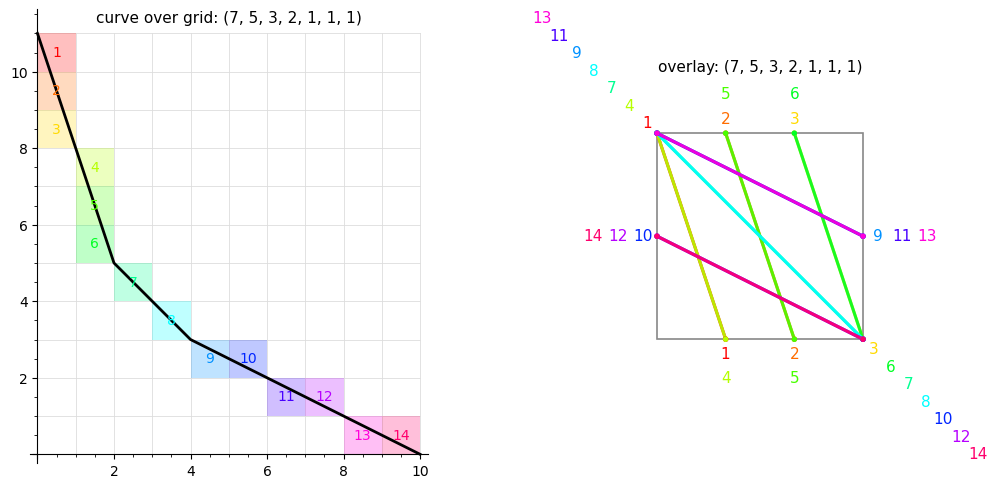

via_br^-1 o via_tl (one-line): [9, 10, 11, 1, 2, 7, 8, 12, 13, 14, 3, 4, 5, 6]
list1: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
list2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


In [3]:
lam = [7,5,3,2,1,1,1]

# concave_hull does it all: prints concavity (and draws the figure when plot=True).
# Assigning the result keeps the details (curve, etc.) without echoing the dict.
details = concave_hull(lam, False)     # plot=False here -> no partition figure


# ── boundary permutation ─────────────────────────────────────

def boundary_permutation(details):
    """
    Treat the two boundary walks from boundary_lists as permutations of
    1..n in one-line notation (position i -> label list[i-1]), and return

        (via_br)^{-1} o via_tl

    i.e. result(i) = via_br^{-1}( via_tl(i) ): the position that via_tl's
    i-th label occupies in via_br.  Returned as a list in one-line
    notation (1-based values).
    """
    via_tl, via_br = overlay(details)
    #print("via_tl", via_tl, "via_br", via_br)
    pos_in_br = {label: j + 1 for j, label in enumerate(via_br)}   # via_br^{-1}
    return [pos_in_br[label] for label in via_tl]


perm = boundary_permutation(details)
print("via_br^-1 o via_tl (one-line):", perm)


# ── 0/1 sequences for knots-torus ────────────────────────────

def torus_sequences(details):
    """
    Build the two 0/1 sequences consumed by knots-torus (TorusKnot's
    list1, list2) by reading ONLY the left edge and the bottom edge of the
    overlaid unit square -- points on the top and right edges are NOT
    included:

        list1  (left edge,  x=0, bottom -> top)  : all 0 except a single 1
               at the position of label 1
        list2  (bottom edge, y=0, left -> right) : all 0 except a single 1
               at the position of the biggest label

    Corner convention: the bottom-right corner counts as the bottom edge
    (its exit has y=0); the top-right corner would count as the left edge.
    Label 1 is the curve's start, always on the left edge, and the biggest
    label is the curve's end, always on the bottom edge -- so each marker
    is always present.  Where labels share a point the smaller comes
    first.  list1 and list2 may have different lengths.

    Returns (list1, list2).
    """
    arcs = curve_arcs(details)
    n = len(arcs)
    left, bottom = {}, {}
    for a in arcs:
        ex, ey = a['local'][0]          # entry: left edge iff x == 0
        if ex == 0:
            left.setdefault(ey, []).append(a['index'])
        fx, fy = a['local'][-1]         # exit: bottom edge iff y == 0
        if fy == 0:
            bottom.setdefault(fx, []).append(a['index'])

    left_labels   = [i for y in sorted(left)   for i in sorted(left[y])]    # bottom -> top
    bottom_labels = [i for x in sorted(bottom) for i in sorted(bottom[x])]  # left -> right

    list1 = [1 if lbl == 1 else 0 for lbl in left_labels]    # 1 marks label 1
    list2 = [1 if lbl == n else 0 for lbl in bottom_labels]  # 1 marks the biggest label
    return list1, list2


list1, list2 = torus_sequences(details)
print("list1:", list1)
print("list2:", list2)
